# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [47]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy import stats
from scipy.stats import linregress
from pprint import pprint

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [20]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 591


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [ ]:


url = f'https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}'
city_weather = requests.get(url).json()
pprint(city_weather)

{'base': 'stations',
 'clouds': {'all': 40},
 'cod': 200,
 'coord': {'lat': -17.8, 'lon': -63.1667},
 'dt': 1736795849,
 'id': 3904906,
 'main': {'feels_like': 308.85,
          'grnd_level': 956,
          'humidity': 55,
          'pressure': 1004,
          'sea_level': 1004,
          'temp': 305.18,
          'temp_max': 305.85,
          'temp_min': 305.18},
 'name': 'Santa Cruz de la Sierra',
 'sys': {'country': 'BO',
         'id': 8616,
         'sunrise': 1736761711,
         'sunset': 1736808837,
         'type': 1},
 'timezone': -14400,
 'visibility': 10000,
 'weather': [{'description': 'scattered clouds',
              'icon': '03d',
              'id': 802,
              'main': 'Clouds'}],
 'wind': {'deg': 20, 'speed': 2.57}}


In [24]:
# Set the API base URL
url = f'https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}'

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f'https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}&units=metric'

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather['coord']['lat']
        city_lng = city_weather['coord']['lon']
        city_max_temp = city_weather['main']['temp_max']
        city_humidity = city_weather['main']['humidity']
        city_clouds = city_weather['clouds']['all']
        city_wind = city_weather['wind']['speed']
        city_country = city_weather['sys']['country']
        city_date = city_weather['dt']

        # Append the City information into city_data list
        city_data.append({"City": city,
                        "Lat": city_lat,
                        "Lng": city_lng,
                        "Max Temp": city_max_temp,
                        "Humidity": city_humidity,
                        "Cloudiness": city_clouds,
                        "Wind Speed": city_wind,
                        "Country": city_country,
                        "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | mora
Processing Record 2 of Set 1 | metlili chaamba
Processing Record 3 of Set 1 | hassi messaoud
Processing Record 4 of Set 1 | ust-nera
Processing Record 5 of Set 1 | port mathurin
Processing Record 6 of Set 1 | taiohae
City not found. Skipping...
Processing Record 7 of Set 1 | richards bay
Processing Record 8 of Set 1 | port-aux-francais
Processing Record 9 of Set 1 | ribeira grande
Processing Record 10 of Set 1 | atafu village
Processing Record 11 of Set 1 | edinburgh of the seven seas
Processing Record 12 of Set 1 | qaqortoq
Processing Record 13 of Set 1 | puerto ayora
Processing Record 14 of Set 1 | iqaluit
Processing Record 15 of Set 1 | wlodawa
Processing Record 16 of Set 1 | waitangi
Processing Record 17 of Set 1 | enewetak
Processing Record 18 of Set 1 | baruun-urt
Processing Record 19 of Set 1 | petropavlovsk-kamchatsky
Processing Record 20 of Set 1 | adamstown
Processing Record 21 of 

In [26]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          564
Lat           564
Lng           564
Max Temp      564
Humidity      564
Cloudiness    564
Wind Speed    564
Country       564
Date          564
dtype: int64

In [73]:
# Display sample data 
# convert datetime to readablw date format
city_data_df['Date']=(pd.to_datetime(city_data_df['Date'], unit='s')).dt.date

city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,mora,11.0461,14.1401,23.02,22,21,1.65,CM,2025-01-13
1,metlili chaamba,32.2667,3.6333,9.52,46,40,3.60,DZ,2025-01-13
2,hassi messaoud,31.6804,6.0729,9.92,43,1,1.03,DZ,2025-01-13
3,ust-nera,64.5667,143.2000,-34.22,94,99,0.96,RU,2025-01-13
4,port mathurin,-19.6833,63.4167,26.10,79,6,7.65,MU,2025-01-13


In [74]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [75]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,mora,11.0461,14.1401,23.02,22,21,1.65,CM,2025-01-13
1,metlili chaamba,32.2667,3.6333,9.52,46,40,3.60,DZ,2025-01-13
2,hassi messaoud,31.6804,6.0729,9.92,43,1,1.03,DZ,2025-01-13
3,ust-nera,64.5667,143.2000,-34.22,94,99,0.96,RU,2025-01-13
4,port mathurin,-19.6833,63.4167,26.10,79,6,7.65,MU,2025-01-13


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

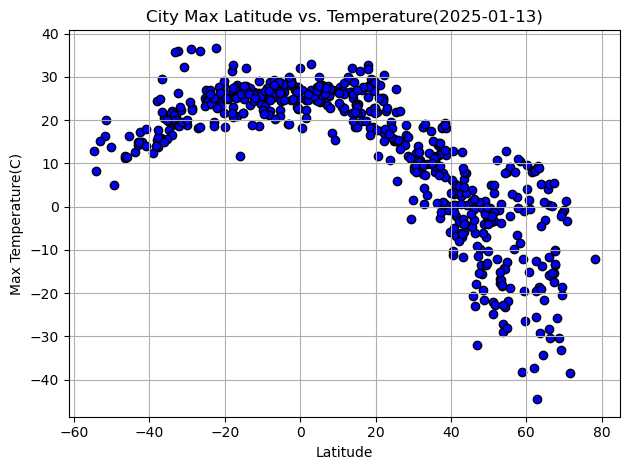

In [78]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df['Lat'], city_data_df['Max Temp'], marker='o', facecolors="b", edgecolors="k")

# Incorporate the other graph properties
plt.grid()
plt.xlabel("Latitude")
plt.ylabel("Max Temperature(C)")
date=city_data_df["Date"].min()
plt.title(f"City Max Latitude vs. Temperature({date})")

plt.tight_layout()

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

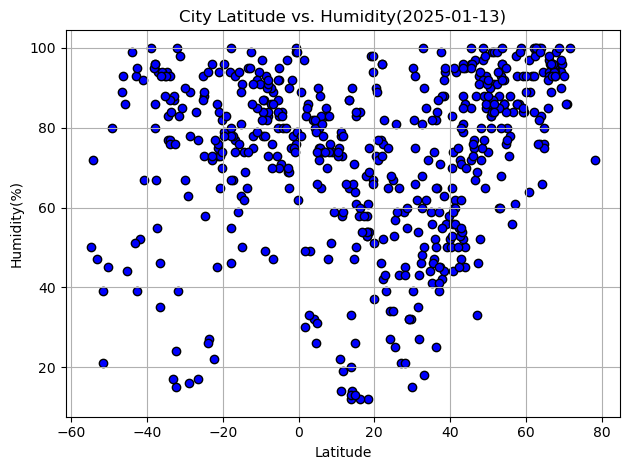

In [79]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df['Lat'], city_data_df['Humidity'], marker="o", facecolors="b", edgecolors="k")

# Incorporate the other graph properties
plt.grid()
plt.xlabel("Latitude")
plt.ylabel("Humidity(%)")
date=city_data_df["Date"].min()
plt.title(f"City Latitude vs. Humidity({date})")

plt.tight_layout()



# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

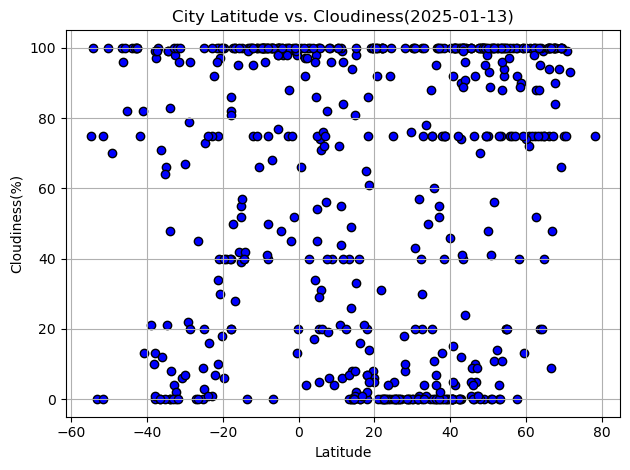

In [80]:
# Build the scatter plots for latitude vs. cloudiness

plt.scatter(city_data_df['Lat'], city_data_df['Cloudiness'], marker="o", facecolors="b", edgecolors="k")

# Incorporate the other graph properties
plt.grid()
plt.xlabel("Latitude")
plt.ylabel("Cloudiness(%)")
plt.title(f"City Latitude vs. Cloudiness({date})")
date=city_data_df["Date"].min()
plt.tight_layout()


# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

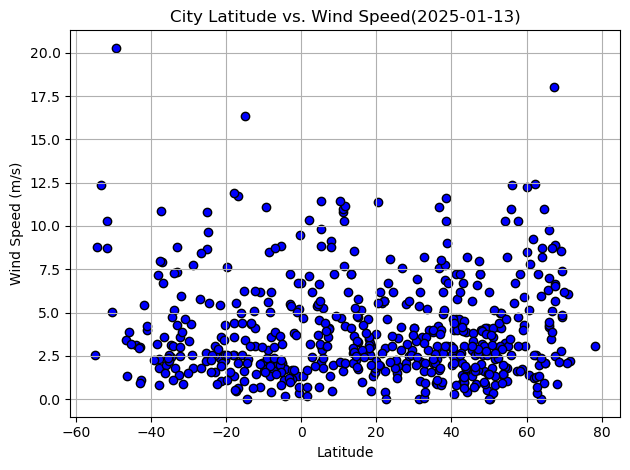

In [81]:
# Build the scatter plots for latitude vs. wind speed

plt.scatter(city_data_df['Lat'], city_data_df['Wind Speed'], marker="o", facecolors="b", edgecolors="k")

# Incorporate the other graph properties
plt.grid()
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.title(f"City Latitude vs. Wind Speed({date})")
date=city_data_df["Date"].min()
plt.tight_layout()



# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [82]:
# Define a function to create Linear Regression plots


line_eq='y=' +str(round(slope,2)) + 'x+' +str(round(intercept,2))



In [83]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df=city_data_df.loc[city_data_df['Lat']>=0, :]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,mora,11.0461,14.1401,23.02,22,21,1.65,CM,2025-01-13
1,metlili chaamba,32.2667,3.6333,9.52,46,40,3.60,DZ,2025-01-13
2,hassi messaoud,31.6804,6.0729,9.92,43,1,1.03,DZ,2025-01-13
3,ust-nera,64.5667,143.2000,-34.22,94,99,0.96,RU,2025-01-13
7,ribeira grande,38.5167,-28.7000,19.22,88,75,10.28,PT,2025-01-13


In [84]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df=city_data_df.loc[city_data_df['Lat']<=0,:]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
4,port mathurin,-19.6833,63.4167,26.10,79,6,7.65,MU,2025-01-13
5,richards bay,-28.7830,32.0377,22.75,89,96,1.79,ZA,2025-01-13
6,port-aux-francais,-49.3500,70.2167,5.08,80,70,20.28,TF,2025-01-13
8,atafu village,-8.5421,-172.5159,25.42,93,100,8.49,TK,2025-01-13
9,edinburgh of the seven seas,-37.0676,-12.3116,15.74,94,100,7.91,SH,2025-01-13


###  Temperature vs. Latitude Linear Regression Plot

The r^2-value is: 0.6963759614592768


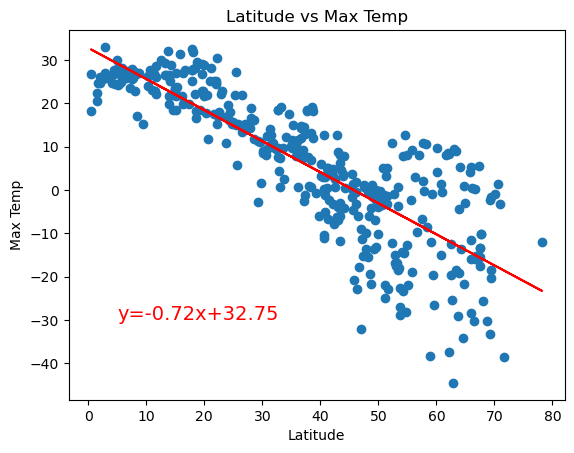

In [56]:
# Linear regression on Northern Hemisphere

x_values= northern_hemi_df['Lat']
y_values=northern_hemi_df['Max Temp']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept


plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Max Temp')
plt.title('Latitude vs Max Temp')
plt.annotate(line_eq,(5,-30), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()


The r^2-value is: 0.36535877413896417


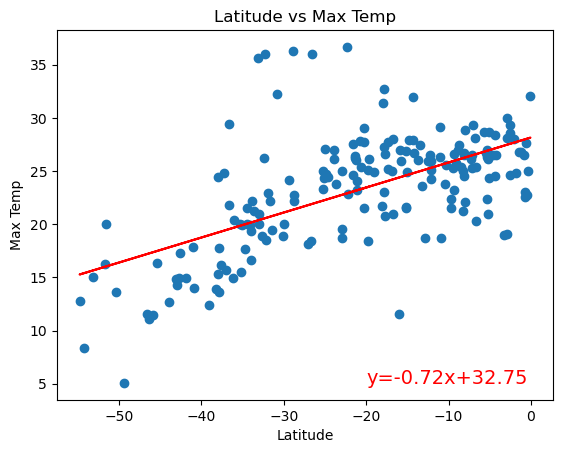

In [59]:
# Linear regression on Southern Hemisphere

x_values= southern_hemi_df['Lat']
y_values=southern_hemi_df['Max Temp']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot graph
plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Max Temp')
plt.title('Latitude vs Max Temp')
plt.annotate(line_eq,(-20,5), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()

**Discussion about the linear relationship:** Maximum Temperatures increases as we approach the equator, in the
Northern Hemisphere, it is a negative correlation while in the southern Hemisphere, it is a positive one.

### Humidity vs. Latitude Linear Regression Plot

The r^2-value is: 0.2057956263897534


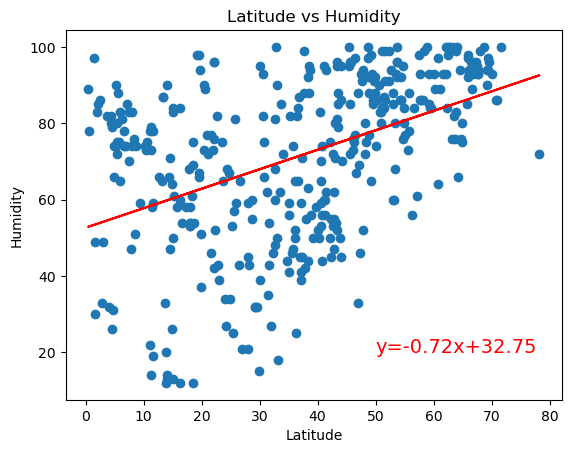

In [68]:
# Northern Hemisphere
x_values= northern_hemi_df['Lat']
y_values=northern_hemi_df['Humidity']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot
plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Humidity')
plt.title('Latitude vs Humidity')
plt.annotate(line_eq,(50,20), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()

The r^2-value is: 0.05180125402579683


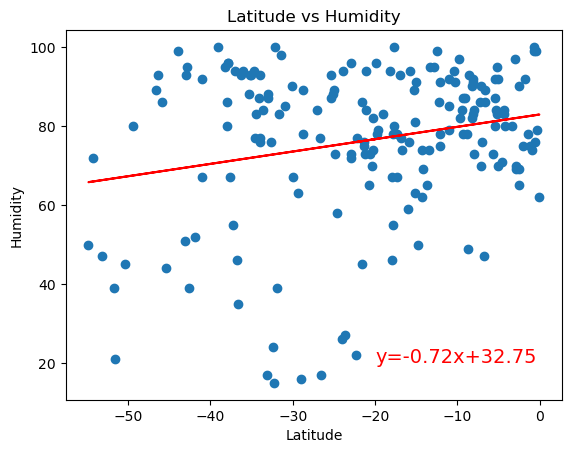

In [65]:
# Southern Hemisphere
x_values= southern_hemi_df['Lat']
y_values= southern_hemi_df['Humidity']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot

plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Humidity')
plt.title('Latitude vs Humidity')
plt.annotate(line_eq,(-20,20), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()






**Discussion about the linear relationship:** there is little to no relationship between latitude and humidity based on the data.
there is a slight positive correlation for each hemisphere which shows, proximity to equator has no bearing on humidity

### Cloudiness vs. Latitude Linear Regression Plot

The r^2-value is: 0.06566852849686208


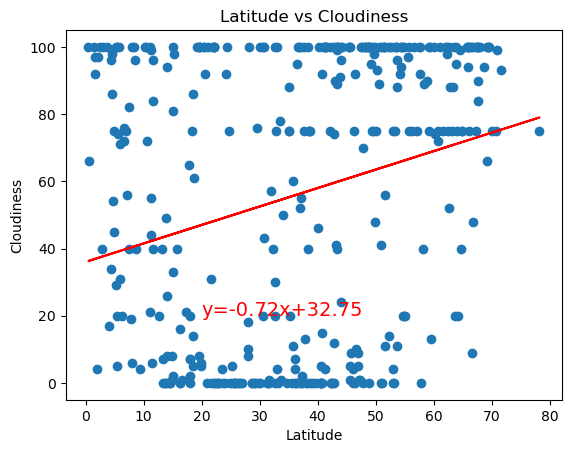

In [66]:
# Northern Hemisphere
x_values= northern_hemi_df['Lat']
y_values= northern_hemi_df['Cloudiness']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot

plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Cloudiness')
plt.title('Latitude vs Cloudiness')
plt.annotate(line_eq,(20,20), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()

The r^2-value is: 0.018616831531634456


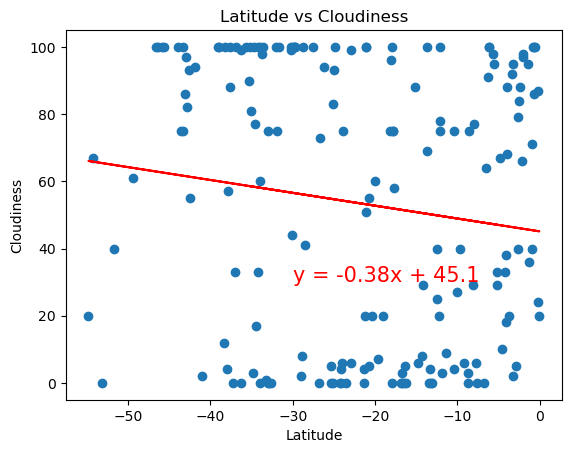

In [20]:
# Southern Hemisphere
x_values= southern_hemi_df['Lat']
y_values= southern_hemi_df['Cloudiness']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot

plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Cloudiness')
plt.title('Latitude vs Cloudiness')
plt.annotate(line_eq,(-20,20), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()

**Discussion about the linear relationship:** There is little to no relationship between latitude and cloudiness based on the data.
there is a slight positive correlation for each hemisphere which shows, proximity to equator has no bearing on cloudiness

### Wind Speed vs. Latitude Linear Regression Plot

The r^2-value is: 0.0011962510360200237


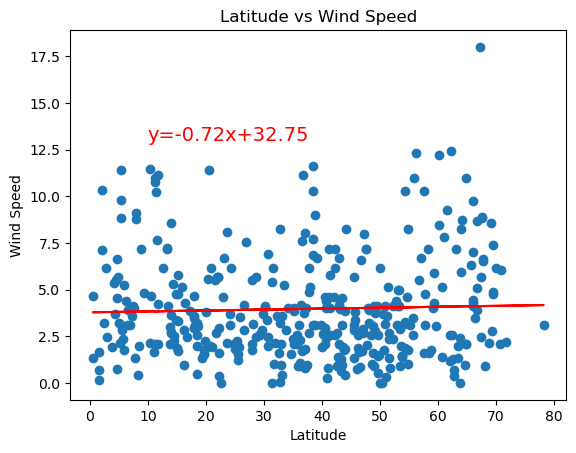

In [70]:
# Northern Hemisphere
x_values= northern_hemi_df['Lat']
y_values= northern_hemi_df['Wind Speed']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot

plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Wind Speed')
plt.title('Latitude vs Wind Speed')
plt.annotate(line_eq,(10,13), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()

The r^2-value is: 0.04277738087468078


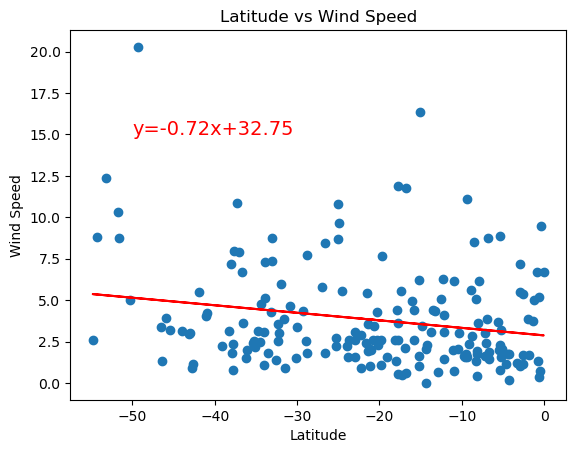

In [71]:
# Southern Hemisphere
x_values= southern_hemi_df['Lat']
y_values= southern_hemi_df['Wind Speed']

(slope, intercept, rvalue, pvalue, stderr)=stats.linregress(x_values, y_values)

regress_values = x_values * slope + intercept

#plot

plt.scatter(x_values, y_values)
plt.plot(x_values, regress_values, 'r-')
plt.xlabel('Latitude')
plt.ylabel('Wind Speed')
plt.title('Latitude vs Wind Speed')
plt.annotate(line_eq,(-50,15), fontsize=14, color='red')


print(f'The r^2-value is: {rvalue**2}')
plt.show()

**Discussion about the linear relationship:** The r-value is low for both hemisphere, and scatter points to show data is widely spread,
There is little to no relationship between latitude and wind speed based on the data.